In [32]:
import csv
import gzip
from pathlib import Path
import random

import gffutils
import numpy as np
import plotly.express as px
import polars as pl
from safetensors.torch import load_file
from scipy.stats import entropy
import seaborn as sns
from statannotations.Annotator import Annotator
from tqdm import tqdm
from umap import UMAP

import torch

## Load annotations

In [2]:
with open("/users/cn/itrujnara/genomes-project/infer_chromosome/compare_gff/encode_chr21.bed", newline='') as f:
    reader = csv.reader(f, delimiter='\t')
    bed_features = []
    for line in reader:
        bed_features.append(line)

In [3]:
gff_db = gffutils.FeatureDB("/users/cn/itrujnara/genomes-project/infer_chromosome/compare_gff/gencode.v48.chr21.db")

## Utility functions

In [4]:
basepath = Path("/no_backup/rg/itrujnara/infer_chromosome/tensors")

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
size = 2**20
stride = size - 8192
chr_size = 46709983

In [7]:
def get_bed_ranges(bed, feature_types, **kwargs):
    feature_ranges = []
    for feature in bed:
        if feature[9] not in feature_types:
            continue
        feature_ranges.append((int(feature[1]) - 1, int(feature[2]) - 1))
    
    return feature_ranges

In [8]:
def get_feature_embeddings(range_func, *args, **kwargs):
    ranges = range_func(*args, **kwargs)

    sample_size = kwargs.get("sample_size", 100)
    seed = kwargs.get("seed", 42)

    indices = np.concatenate([np.arange(start,end) for start,end in ranges])
    rng = np.random.default_rng()
    sample = np.sort(rng.choice(indices, size=sample_size))

    all_embeddings = []

    for start in tqdm(range(0,chr_size,stride)):
        offset = start + 8192
        end = start + size
        filename = f"ch38_chr21_{start}_{end}_embeddings.safetensors"

        try:
            chunk_embeddings = load_file(basepath / filename)["embeddings"]
        except FileNotFoundError:
            print(f"{filename} not found")
            continue

        for index in sample:
            if index >= end:
                break
            if index > offset:
                offset_idx = index - offset
                index_embeddings = chunk_embeddings[offset_idx,:].unsqueeze(0)
                all_embeddings.append(index_embeddings)

        del chunk_embeddings

    return torch.cat(all_embeddings, 0), sample

In [9]:
def get_feature_ranges(gff_db, feature_type, gene_type=None, exclude_type=None, **kwargs):
    feature_ranges = []
    for feature in gff_db.features_of_type(feature_type):
        if gene_type is not None and gene_type not in feature["gene_type"]:
            continue
        if exclude_type is not None and exclude_type in feature["gene_type"]:
            continue
        feature_ranges.append((feature.start, feature.end))
    
    return feature_ranges

In [10]:
def get_intergenic_ranges(gff_db, **kwargs):
    feature_ranges = []
    for feature in gff_db.interfeatures(gff_db.merge(gff_db.features_of_type('gene', order_by=('seqid', 'start')))):
        feature_ranges.append((feature.start, feature.end))

    return feature_ranges

In [44]:
def tensor_to_df(tensor, index, label):
    return pl.DataFrame({"embedding": tensor.numpy(), "index": index, "label": [label] * tensor.shape[0]})

In [21]:
def embed_dfs(dfs, reducer):
    df_all = pl.concat(dfs).with_columns(pl.col("embedding").arr.to_struct()).unnest("embedding")
    umap_embedding = reducer.fit_transform(df_all.select(pl.exclude("label", "index")))
    df_all_umap = pl.DataFrame(umap_embedding).hstack(df_all.select("label", "index"))
    return df_all_umap

In [23]:
def plot_umap(df_umap):
    ax = sns.scatterplot(df_umap, x="column_0", y="column_1", hue="label", s=8)

    ax.set_title("DNA features in embedding space")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="Feature")

    return ax

In [30]:
def plot_umap_interactive(df_umap):
    return px.scatter(df_umap, x="column_0", y="column_1", color="label",
                     hover_data={"column_0": True, "column_1": True, "label": True, "index": True})

## Analysis

In [45]:
pc_exon_emb, pc_exon_idx = get_feature_embeddings(get_feature_ranges, gff_db, "exon", gene_type="protein_coding", sample_size=1000)
df_pc = tensor_to_df(pc_exon_emb, pc_exon_idx, "Protein-coding exon")

100%|██████████| 45/45 [00:00<00:00, 1957.37it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [46]:
lnc_exon_emb, lnc_idx = get_feature_embeddings(get_feature_ranges, gff_db, "exon", gene_type="lncRNA", sample_size=1000)
df_lnc = tensor_to_df(lnc_exon_emb, lnc_idx, "lncRNA exon")

100%|██████████| 45/45 [00:00<00:00, 1679.51it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [47]:
intergenic_emb, intergenic_idx = get_feature_embeddings(get_intergenic_ranges, gff_db, sample_size=1000)
df_intergenic = tensor_to_df(intergenic_emb, intergenic_idx, "Intergenic region")

100%|██████████| 45/45 [00:00<00:00, 1777.16it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [48]:
enhancer_emb, enhancer_idx = get_feature_embeddings(get_bed_ranges, bed_features, ["pELS", "dELS"], sample_size=1000)
df_enhancer = tensor_to_df(enhancer_emb, enhancer_idx, "Enhancer")

100%|██████████| 45/45 [00:00<00:00, 1800.20it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


In [49]:
reducer = UMAP(min_dist=0.4, metric="cosine", random_state=42)

In [50]:
df_with_enhancer = embed_dfs((df_pc, df_lnc, df_intergenic, df_enhancer), reducer)

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

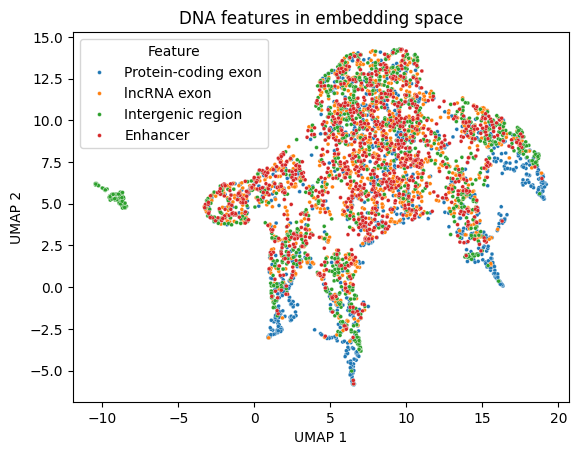

In [51]:
plot_umap(df_with_enhancer)

In [52]:
plot_umap_interactive(df_with_enhancer)

## More cCRE types

In [21]:
promoter_emb = get_feature_embeddings(get_bed_ranges, bed_features, ["PLS"], sample_size=1000)
df_promoter = tensor_to_df(promoter_emb, "Promoter")

100%|██████████| 45/45 [00:00<00:00, 1897.26it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

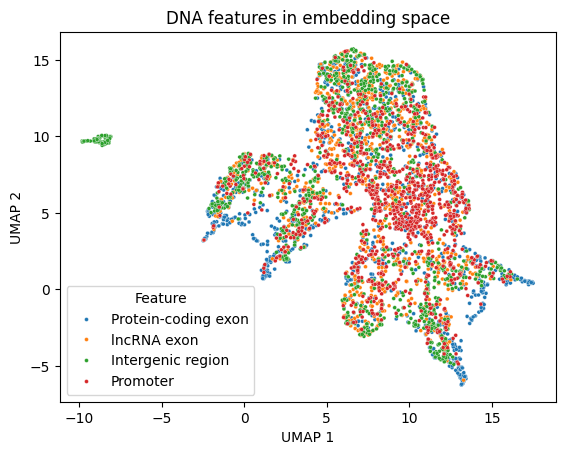

In [22]:
df_with_promoter = embed_dfs((df_pc, df_lnc, df_intergenic, df_promoter), reducer)
plot_umap(df_with_promoter)

In [23]:
tfbs_emb = get_feature_embeddings(get_bed_ranges, bed_features, ["TF", "CA-TF"], sample_size=1000)
df_tfbs = tensor_to_df(tfbs_emb, "TFBS")

100%|██████████| 45/45 [00:00<00:00, 1936.31it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

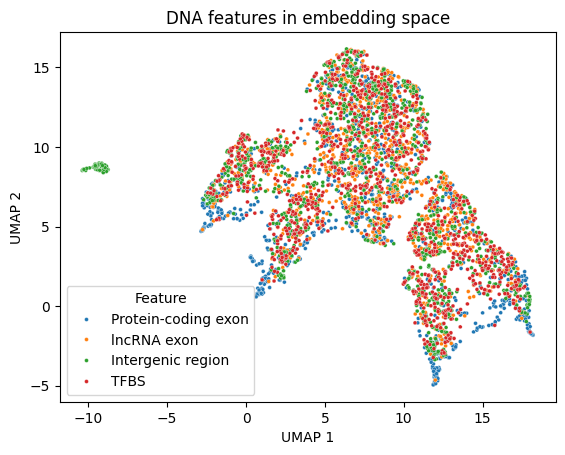

In [24]:
df_with_tfbs = embed_dfs((df_pc, df_lnc, df_intergenic, df_tfbs), reducer)
plot_umap(df_with_tfbs)

In [25]:
acc_emb = get_feature_embeddings(get_bed_ranges, bed_features, ["CA", "CA-TF"], sample_size=1000)
df_acc = tensor_to_df(acc_emb, "Accessible chromatin")

100%|██████████| 45/45 [00:00<00:00, 1915.52it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

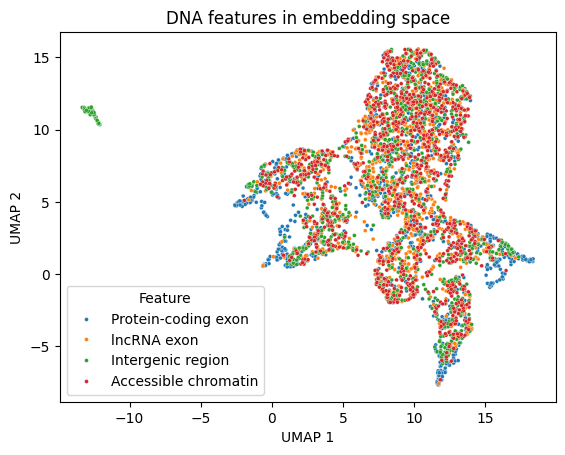

In [26]:
df_with_acc = embed_dfs((df_pc, df_lnc, df_intergenic, df_acc), reducer)
plot_umap(df_with_acc)

In [27]:
h3k4_emb = get_feature_embeddings(get_bed_ranges, bed_features, ["CA-H3K4me3"], sample_size=1000)
df_h3k4 = tensor_to_df(acc_emb, "H3K4me3")

100%|██████████| 45/45 [00:00<00:00, 1733.63it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

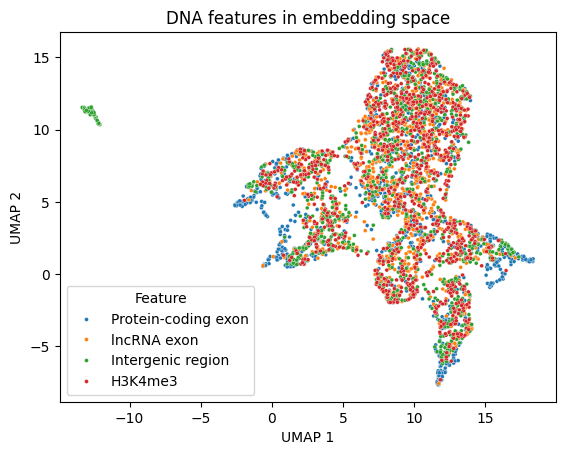

In [28]:
df_with_h3k4 = embed_dfs((df_pc, df_lnc, df_intergenic, df_h3k4), reducer)
plot_umap(df_with_h3k4)

In [29]:
ctcf_emb = get_feature_embeddings(get_bed_ranges, bed_features, ["CA-CTCF"], sample_size=1000)
df_ctcf = tensor_to_df(ctcf_emb, "CTCF")

100%|██████████| 45/45 [00:00<00:00, 1865.37it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

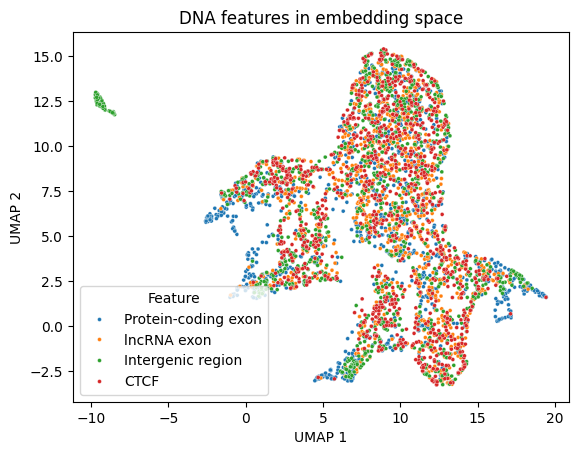

In [30]:
df_with_ctcf = embed_dfs((df_pc, df_lnc, df_intergenic, df_ctcf), reducer)
plot_umap(df_with_ctcf)

## Pairs with intergenic

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

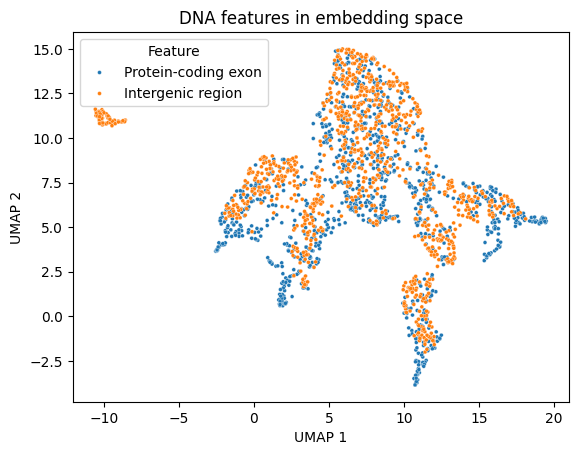

In [31]:
df_pc_intergenic = embed_dfs((df_pc, df_intergenic), reducer)
plot_umap(df_pc_intergenic)

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

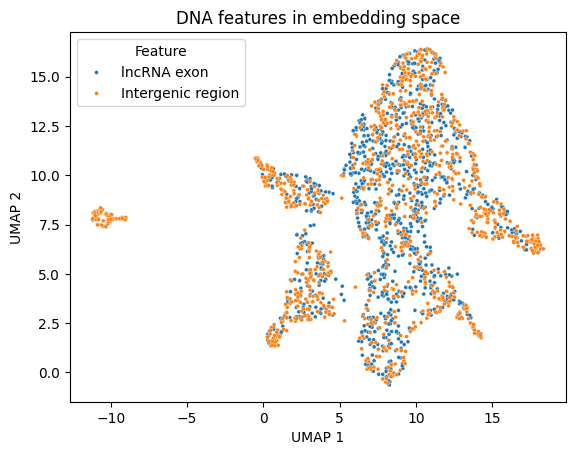

In [32]:
df_lnc_intergenic = embed_dfs((df_lnc, df_intergenic), reducer)
plot_umap(df_lnc_intergenic)

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

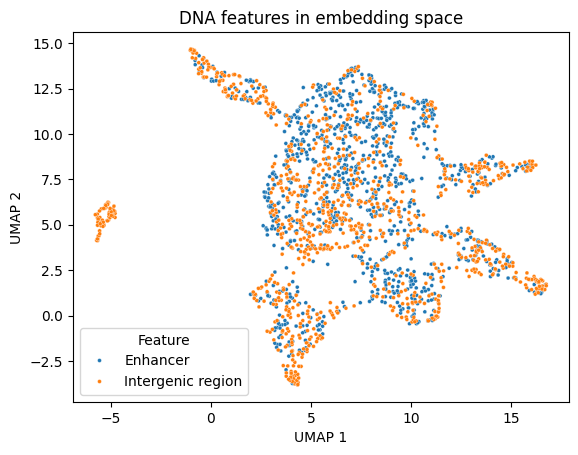

In [33]:
df_enhancer_intergenic = embed_dfs((df_enhancer, df_intergenic), reducer)
plot_umap(df_enhancer_intergenic)

## cCRE contrasts

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

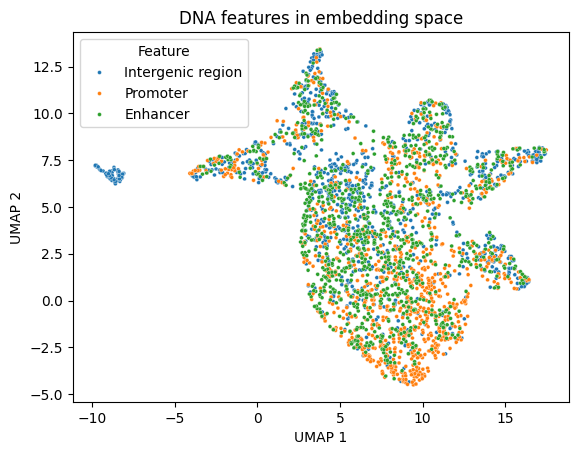

In [34]:
df_promoter_enhancer = embed_dfs((df_intergenic, df_promoter, df_enhancer), reducer)
plot_umap(df_promoter_enhancer)

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

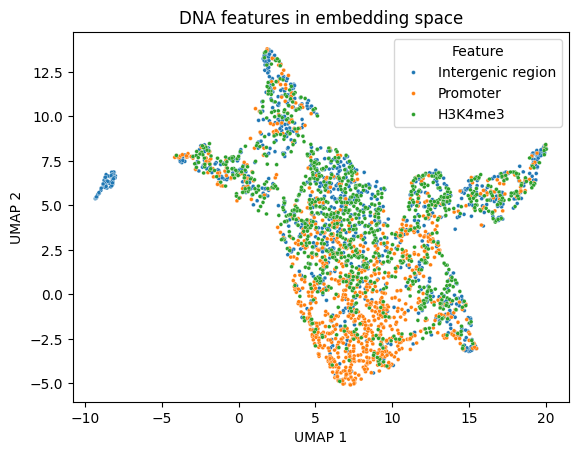

In [35]:
df_promoter_h3k4 = embed_dfs((df_intergenic, df_promoter, df_h3k4), reducer)
plot_umap(df_promoter_h3k4)

/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

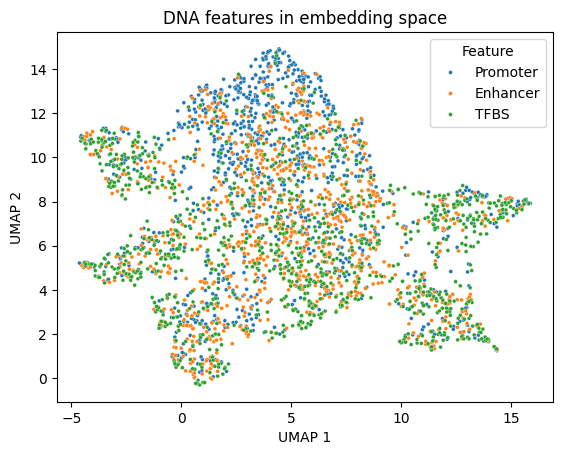

In [36]:
df_prom_enh_tfbs = embed_dfs((df_promoter, df_enhancer, df_tfbs), reducer)
plot_umap(df_prom_enh_tfbs)

In [37]:
intergenic_emb_2 = get_feature_embeddings(get_intergenic_ranges, gff_db, sample_size=1000, seed=2137)
df_intergenic_2 = tensor_to_df(intergenic_emb_2, "Intergenic region")

100%|██████████| 45/45 [00:00<00:00, 1817.59it/s]


ch38_chr21_0_1048576_embeddings.safetensors not found
ch38_chr21_1040384_2088960_embeddings.safetensors not found
ch38_chr21_2080768_3129344_embeddings.safetensors not found
ch38_chr21_3121152_4169728_embeddings.safetensors not found


/users/cn/itrujnara/envs/venv_gpu/lib64/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


<Axes: title={'center': 'DNA features in embedding space'}, xlabel='UMAP 1', ylabel='UMAP 2'>

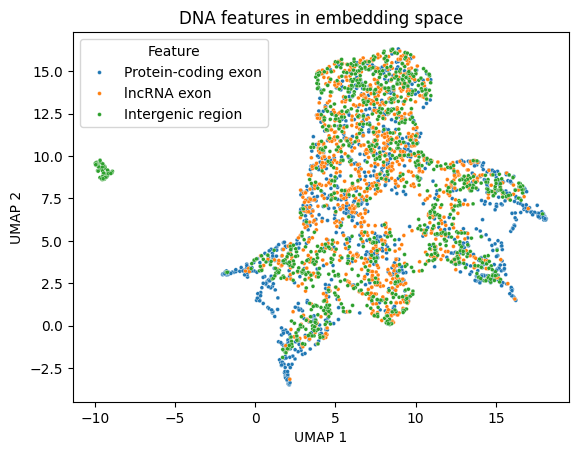

In [38]:
df_inter2 = embed_dfs((df_pc, df_lnc, df_intergenic_2), reducer)
plot_umap(df_inter2)